## Норми векторів

In [1]:
import numpy as np

# Приклад вектора
x = np.array([1, 2, 3, 4, 5])

# Евклідова норма (L2-норма)
l2_norm = np.linalg.norm(x)

# Манхеттенська норма (L1-норма)
l1_norm = np.linalg.norm(x, ord=1)

# Максимальна норма (L∞-норма)
max_norm = np.linalg.norm(x, ord=np.inf)

print("Евклідова норма:", l2_norm)
print("Манхеттенська норма:", l1_norm)
print("Максимальна норма:", max_norm)


Евклідова норма: 7.416198487095663
Манхеттенська норма: 15.0
Максимальна норма: 5.0


**Норма Фробеніуса для матриць**

In [2]:
from math import sqrt
import numpy as np

# Function to return the Frobenius
# Norm of the given matrix
def frobeniusNorm(mat):

    row = np.shape(mat)[0]
    col = np.shape(mat)[1]
    # To store the sum of squares of the
    # elements of the given matrix
    sumSq = 0
    for i in range(row):
        for j in range(col):
            sumSq += pow(mat[i][j], 2)

    # Return the square root of
    # the sum of squares
    res = sqrt(sumSq)
    return round(res, 5)

# Driver code

mat = [ [ 1, 2, 3 ], [ 4, 5, 6 ] ]

print(frobeniusNorm(mat))

9.53939


## Стандартизація/нормалізація даних

Згенеруємо дані з ознаками різного діапазону

In [3]:
import pandas as pd
import numpy as np

# Задаємо розмір датафрейму
num_samples = 100

# Генеруємо дані для кожної ознаки з різним діапазоном значень
feature1 = np.random.randint(0, 100, num_samples)  # Діапазон 0-100
feature2 = np.random.randint(-50, 50, num_samples)  # Діапазон -50-50
feature3 = np.random.uniform(0, 1, num_samples)    # Діапазон 0-1
feature4 = np.random.uniform(-10, 10, num_samples) # Діапазон -10-10
feature5 = np.random.normal(50, 10, num_samples)   # Нормальний розподіл з середнім 50 та стандартним відхиленням 10

# Створюємо датафрейм
data = pd.DataFrame({
    'Feature1': feature1,
    'Feature2': feature2,
    'Feature3': feature3,
    'Feature4': feature4,
    'Feature5': feature5
})

# Виводимо перші 5 рядків датафрейму
print(data.head())


   Feature1  Feature2  Feature3  Feature4   Feature5
0         8        49  0.829436  5.300421  50.051544
1        40       -48  0.293448  8.345471  60.555221
2        65        15  0.281798 -2.092976  41.242100
3        31        26  0.863274 -7.977787  42.062104
4        74        48  0.901352 -0.800283  30.849087


In [4]:
data.describe()

,Feature1,Feature2,Feature3,Feature4,Feature5
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,48.280000,4.060000,0.510671,-0.199180,49.852298
std,26.858056,28.292063,0.292100,6.140648,9.027537
min,0.000000,-50.000000,0.034196,-9.811961,27.311210
25%,29.000000,-20.250000,0.281982,-6.391438,44.868876
50%,47.500000,7.500000,0.497895,0.572050,50.244937
75%,68.000000,27.250000,0.751197,5.370242,56.281814
max,98.000000,49.000000,0.972688,9.798571,71.837405


Приклад функції стандартизації/нормалізації

In [18]:
def data_scale(data, scaler_type='norm'):
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import Normalizer
    if scaler_type == 'minmax':
        scaler = MinMaxScaler()
    if scaler_type == 'std':
        scaler = StandardScaler()
    if scaler_type == 'norm':
        scaler = Normalizer()

    scaler.fit(data)
    res = scaler.transform(data)
    return res

In [19]:
data_scaled = data_scale(data)

In [20]:
df_scaled = pd.DataFrame(data_scaled, columns=[data.columns])
print(df_scaled.head())

   Feature1  Feature2  Feature3  Feature4  Feature5
0  0.113149  0.693038  0.011731  0.074967  0.707911
1  0.457609 -0.549131  0.003357  0.095474  0.692765
2  0.828488  0.191190  0.003592 -0.026677  0.525671
3  0.526210  0.441337  0.014654 -0.135419  0.713983
4  0.791857  0.513637  0.009645 -0.008564  0.330109


Результат стандартизації

In [21]:
df_scaled.describe()

,Feature1,Feature2,Feature3,Feature4,Feature5
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.578711,0.060380,0.006821,0.001516,0.659258
std,0.240527,0.374166,0.004222,0.085722,0.154431
min,0.000000,-0.658927,0.000322,-0.170672,0.330109
25%,0.429221,-0.236456,0.003556,-0.071411,0.529408
50%,0.635665,0.099976,0.007081,0.006286,0.680538
75%,0.774424,0.378951,0.009660,0.074301,0.755617
max,0.902312,0.753735,0.016837,0.210085,0.990737


## Метрики подібності

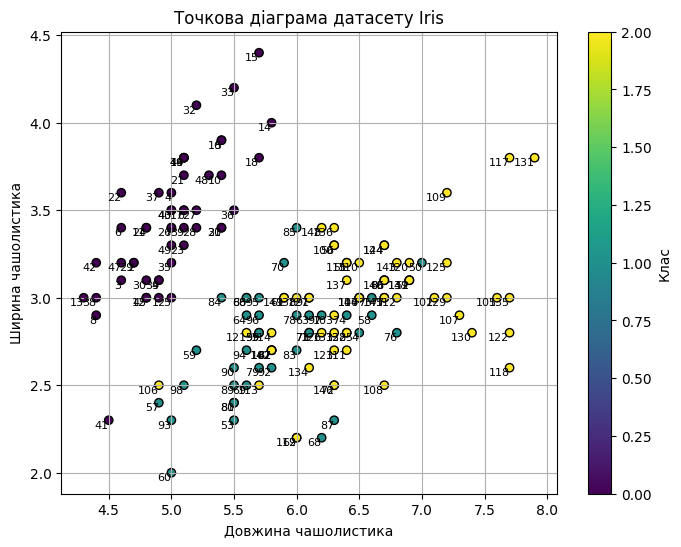

Матриця подібностей:
[[0.  0.7 0.8 ... 7.5 7.3 6.6]
 [0.7 0.  0.5 ... 7.2 7.8 6.3]
 [0.8 0.5 0.  ... 7.7 7.9 6.8]
 ...
 [7.5 7.2 7.7 ... 0.  1.2 0.9]
 [7.3 7.8 7.9 ... 1.2 0.  1.5]
 [6.6 6.3 6.8 ... 0.9 1.5 0. ]]
(150, 150)


In [26]:
from matplotlib import pyplot as plt
from sklearn.datasets import load_iris
from scipy.spatial.distance import euclidean, cityblock, minkowski, jaccard, hamming
import numpy as np

# Завантажимо набір даних Iris
iris = load_iris()
X = iris.data
y = iris.target

# Відображення точкової діаграми для перших двох ознак
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.xlabel('Довжина чашолистика')
plt.ylabel('Ширина чашолистика')
plt.title('Точкова діаграма датасету Iris')

# Додавання номерів спостережень
for i in range(len(X)):
    plt.text(X[i, 0], X[i, 1], str(i), color='black', fontsize=8, ha='right', va='top')

plt.colorbar(label='Клас')
plt.grid(True)
plt.show()


# Обчислимо кількість зразків та ознак
n_samples, n_features = X.shape

# Ініціалізуємо матрицю подібностей
similarity_matrix = np.zeros((n_samples, n_samples))

# Обчислимо матрицю подібностей
for i in range(n_samples):
    for j in range(i, n_samples):
        # Обчислюємо різні метрики подібності
        euclidean_distance = euclidean(X[i], X[j])
        manhattan_distance = cityblock(X[i], X[j])
        minkowski_distance = minkowski(X[i], X[j], p=4)
        jaccard_similarity = jaccard(X[i] > 0, X[j] > 0)
        hamming_distance = hamming(X[i] > 0, X[j] > 0)

        # Додаємо значення метрик до матриці подібностей
        # similarity_matrix[i, j] = euclidean_distance
        # similarity_matrix[j, i] = euclidean_distance

        similarity_matrix[i, j] = manhattan_distance
        similarity_matrix[j, i] = manhattan_distance

        # similarity_matrix[i, j] = minkowski_distance
        # similarity_matrix[j, i] = minkowski_distance

    

        # similarity_matrix[i, j] = hamming_distance
        # similarity_matrix[j, i] = hamming_distance

print("Матриця подібностей:")
print(similarity_matrix)
print(similarity_matrix.shape)


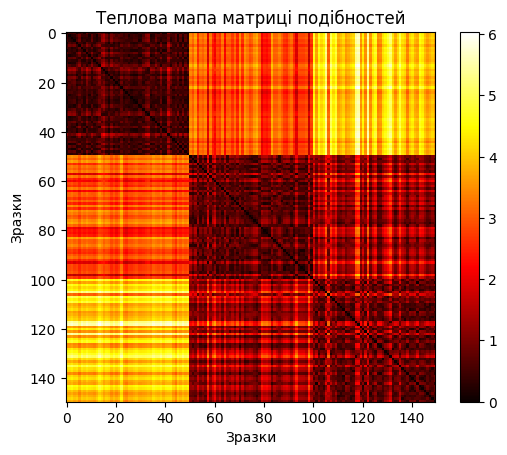

In [10]:
import matplotlib.pyplot as plt

# Відобразимо матрицю подібностей як теплову мапу
plt.imshow(similarity_matrix, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('Теплова мапа матриці подібностей')
plt.xlabel('Зразки')
plt.ylabel('Зразки')
plt.show()


#Кореляція

##Кореляція Пірсона

In [11]:
import numpy as np
from scipy.stats import pearsonr

# Згенеруємо дві змінні з кореляцією
np.random.seed(42)
X = np.random.rand(100)
Y = 2 * X + 1 + 0.1 * np.random.randn(100)

# Розрахунок коефіцієнта кореляції Пірсона
correlation_coefficient, _ = pearsonr(X, Y)

print(f"Коефіцієнт кореляції Пірсона: {correlation_coefficient}")

Коефіцієнт кореляції Пірсона: 0.9881582860812735


https://www.kaggle.com/datasets/russellyates88/suicide-rates-overview-1985-to-2016

In [27]:
# !wget -O suicide-rates.csv "https://drive.usercontent.google.com/download?id=17XCHEogiPblN58LJz-zQicWIRMpfFaJ1&export=download&authuser=0"

In [28]:
import seaborn as sb

df = pd.read_csv("./suicide-rates.csv")


In [29]:
df

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers
...,...,...,...,...,...,...,...,...,...,...,...,...
27815,Uzbekistan,2014,female,35-54 years,107,3620833,2.96,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation X
27816,Uzbekistan,2014,female,75+ years,9,348465,2.58,Uzbekistan2014,0.675,"63,067,077,179",2309,Silent
27817,Uzbekistan,2014,male,5-14 years,60,2762158,2.17,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z
27818,Uzbekistan,2014,female,5-14 years,44,2631600,1.67,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             27820 non-null  object 
 1   year                27820 non-null  int64  
 2   sex                 27820 non-null  object 
 3   age                 27820 non-null  object 
 4   suicides_no         27820 non-null  int64  
 5   population          27820 non-null  int64  
 6   suicides/100k pop   27820 non-null  float64
 7   country-year        27820 non-null  object 
 8   HDI for year        8364 non-null   float64
 9    gdp_for_year ($)   27820 non-null  object 
 10  gdp_per_capita ($)  27820 non-null  int64  
 11  generation          27820 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 2.5+ MB


In [ ]:
df.describe()

,year,suicides_no,population,suicides/100k pop,HDI for year,gdp_per_capita ($)
count,27820.000000,27820.000000,2.782000e+04,27820.000000,8364.000000,27820.000000
mean,2001.258375,242.574407,1.844794e+06,12.816097,0.776601,16866.464414
std,8.469055,902.047917,3.911779e+06,18.961511,0.093367,18887.576472
min,1985.000000,0.000000,2.780000e+02,0.000000,0.483000,251.000000
25%,1995.000000,3.000000,9.749850e+04,0.920000,0.713000,3447.000000
50%,2002.000000,25.000000,4.301500e+05,5.990000,0.779000,9372.000000
75%,2008.000000,131.000000,1.486143e+06,16.620000,0.855000,24874.000000
max,2016.000000,22338.000000,4.380521e+07,224.970000,0.944000,126352.000000


In [ ]:
pearsoncorr = df[['year','population', 'suicides/100k pop', 'HDI for year', 'gdp_per_capita ($)', 'suicides_no'  ]].corr(method='pearson')
pearsoncorr

,year,population,suicides/100k pop,HDI for year,gdp_per_capita ($),suicides_no
year,1.000000,0.008850,-0.039037,0.366786,0.339134,-0.004546
population,0.008850,1.000000,0.008285,0.102943,0.081510,0.616162
suicides/100k pop,-0.039037,0.008285,1.000000,0.074279,0.001785,0.306604
HDI for year,0.366786,0.102943,0.074279,1.000000,0.771228,0.151399
gdp_per_capita ($),0.339134,0.081510,0.001785,0.771228,1.000000,0.061330
suicides_no,-0.004546,0.616162,0.306604,0.151399,0.061330,1.000000


<Axes: >

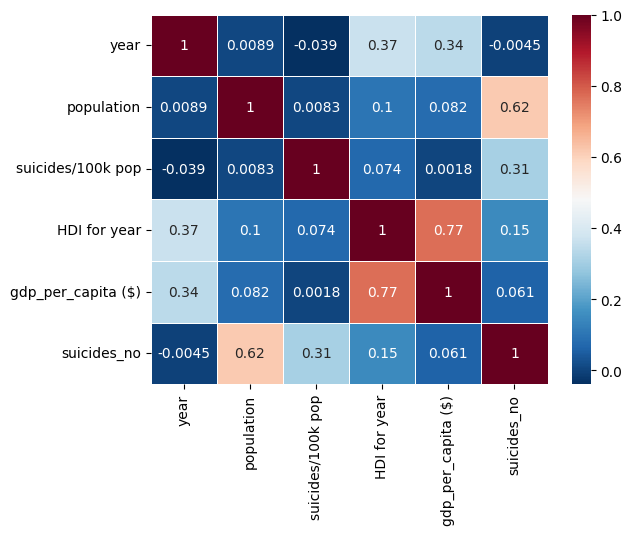

In [ ]:
sb.heatmap(pearsoncorr,
            xticklabels=pearsoncorr.columns,
            yticklabels=pearsoncorr.columns,
            cmap='RdBu_r',
            annot=True,
            linewidth=0.5)

##Приклад обчислення кореляції Кендала на наборі даних

https://www.kaggle.com/datasets/chirin/africa-economic-banking-and-systemic-crisis-data

In [ ]:
!wget -O 'african_crises.csv' "https://drive.usercontent.google.com/download?id=1ZAi5hqYiTjMdpkXdG7wZqbI8w06RkcFN&export=download&authuser=0"

--2025-08-21 17:58:50--  https://drive.usercontent.google.com/download?id=1ZAi5hqYiTjMdpkXdG7wZqbI8w06RkcFN&export=download&authuser=0
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.156.132, 2a00:1450:4013:c1c::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|192.178.156.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66984 (65K) [application/octet-stream]
Saving to: ‘african_crises.csv’

african_crises.csv  100%[===================>]  65.41K  --.-KB/s    in 0.001s  

2025-08-21 17:58:53 (49.1 MB/s) - ‘african_crises.csv’ saved [66984/66984]



In [ ]:
african_crises = pd.read_csv("./african_crises.csv")
african_crises.head()

,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis


In [ ]:
african_crises.banking_crisis.unique()

array(['crisis', 'no_crisis'], dtype=object)

In [ ]:
african_crises['banking_crisis'] = african_crises['banking_crisis'].map({'crisis': 1, 'no_crisis': 0})

In [ ]:
african_crises = african_crises.drop(['cc3', 'country', 'year'], axis=1)
corr = african_crises.corr(method='pearson')

<Axes: >

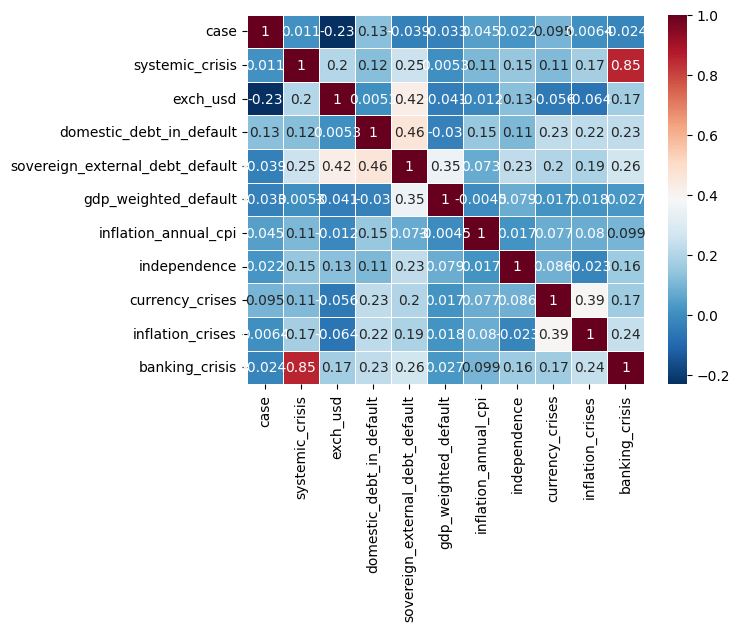

In [ ]:
sb.heatmap(corr, xticklabels=corr.columns.values,
            yticklabels=corr.columns.values,
            cmap='RdBu_r',
            annot=True,
            linewidth=0.5)

## Метод k-means

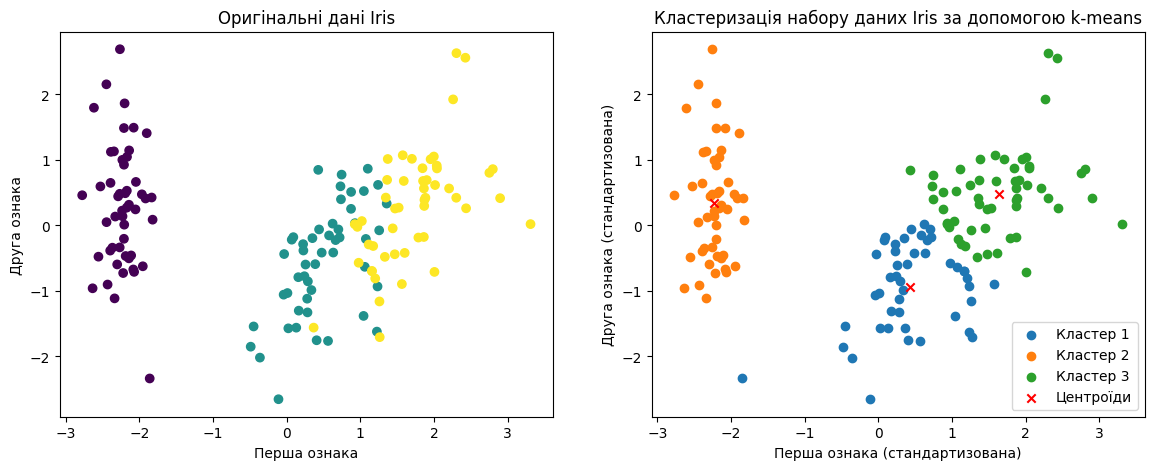

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Завантаження даних Iris
iris = load_iris()
X = iris.data
y = iris.target

# Стандартизація даних
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ініціалізація та навчання моделі k-means

pca = PCA(n_components=2, svd_solver='full')
x_new = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(x_new)

# kmeans.fit(X_scaled)

# Передбачення кластерів для кожного зразка
labels = kmeans.labels_

# Візуалізація результатів
plt.figure(figsize=(14, 5))

# Піддіаграма для оригінальних даних
plt.subplot(1, 2, 1)
plt.scatter(x_new[:, 0], x_new[:, 1], c=y, cmap='viridis')
#plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title('Оригінальні дані Iris')
plt.xlabel('Перша ознака')
plt.ylabel('Друга ознака')

# Піддіаграма для кластеризації
plt.subplot(1, 2, 2)
for i in range(3):
  plt.scatter(x_new[labels == i, 0], x_new[labels == i, 1], label=f'Кластер {i + 1}')
  #plt.scatter(X_scaled[labels == i, 0], X_scaled[labels == i, 1], label=f'Кластер {i + 1}')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color='red', marker='x', label='Центроїди')
plt.title('Кластеризація набору даних Iris за допомогою k-means')
plt.xlabel('Перша ознака (стандартизована)')
plt.ylabel('Друга ознака (стандартизована)')
plt.legend()

plt.show()


#Метод KNN

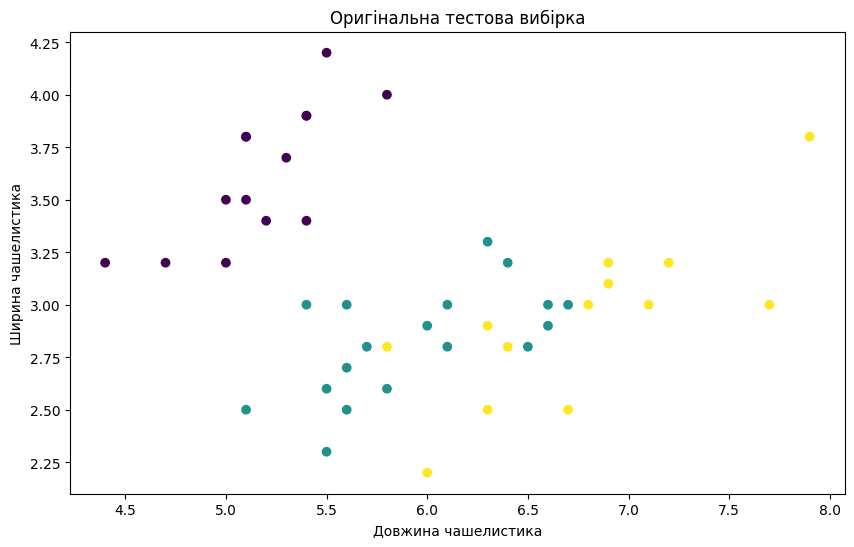

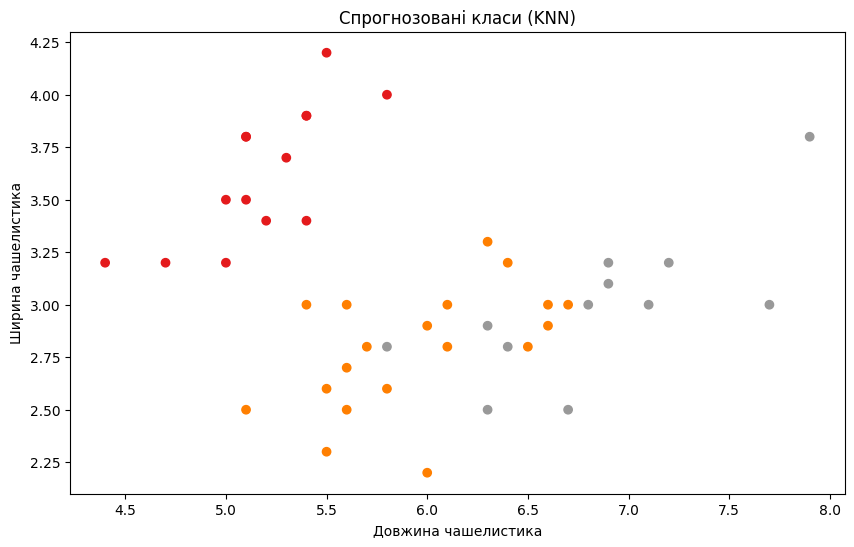

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Завантаження даних Iris
iris = load_iris()
X = iris.data
y = iris.target

# Розбиття на навчальний та тестовий набори
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Стандартизація даних
scaler = StandardScaler() # MinMaxScaler
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ініціалізація та навчання моделі KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

# Передбачення класів для тестових даних
y_pred = knn.predict(X_test_scaled)


# Візуалізація оригінальної тестової вибірки
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis')
plt.title('Оригінальна тестова вибірка')
plt.xlabel('Довжина чашелистика')
plt.ylabel('Ширина чашелистика')
plt.show()

# Візуалізація спрогнозованих класів
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='Set1')
plt.title('Спрогнозовані класи (KNN)')
plt.xlabel('Довжина чашелистика')
plt.ylabel('Ширина чашелистика')
plt.show()


In [ ]:
data collection -> data cleansing (null, nan, noise, outliers) -> data statistics -> data features selection/understanding/engineering ->
 model selection/model training + hyper-params tuning -> model validation -> ... deployment ... (docker, api,...) -> ....

# Додаткові матеріали

1. По коваріації: https://youtu.be/qtaqvPAeEJY?si=dJj7gmV6kre9ekMl
2. Кореляція Пірсона: https://youtu.be/xZ_z8KWkhXE?si=7mPI5Lm1NAUNRTA9
3. Вибір оптимальних кластерів:
https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/
4. Оцінка 'силуету' для кластеризації: https://medium.com/operations-research-bit/optimizing-silhouette-score-computation-in-k-means-clustering-08e1059d8914
5. Curse of dimensionality:  https://towardsdatascience.com/curse-of-dimensionality-a-curse-to-machine-learning-c122ee33bfeb
6.У продовження 'прокляття розмірності':  https://www.analyticsvidhya.com/blog/2021/04/the-curse-of-dimensionality-in-machine-learning/ та
https://towardsdatascience.com/curse-of-dimensionality-an-intuitive-exploration-1fbf155e1411